In [1]:
import os
from PIL import Image

In [2]:
coco_path = "../out/2025-07-11_11-00-55_CUTIAUCMioU" 


path = coco_path

In [3]:
runs = {
    "DCAMA AE": "run_0",
    "DCAMA Saliency": "run_2",
    "DMTNet AE": "run_8",
    "DMTNet Saliency": "run_10",
}
models = ["DMTNet", "DCAMA"]

In [4]:
batches = {
}

In [13]:
chosen_batch = 950
batch_path = f"batch_{chosen_batch}"

image = f"{path}/{runs['DCAMA AE']}/{batch_path}/images.png"
ground_truth = f"{path}/{runs['DCAMA AE']}/{batch_path}/ground_truth.png"

predictions = {
    model: f"{path}/{runs[model + ' AE']}/{batch_path}/segmentation.png"
    for model in models
}

explanations = {
    model_method: f"{path}/{runs[model_method]}/{batch_path}/explanation.png"
    for model_method in runs
}

Left part of image:


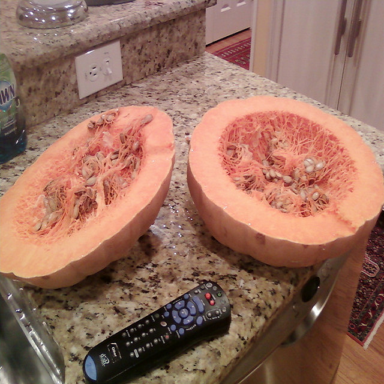

Right part of image:


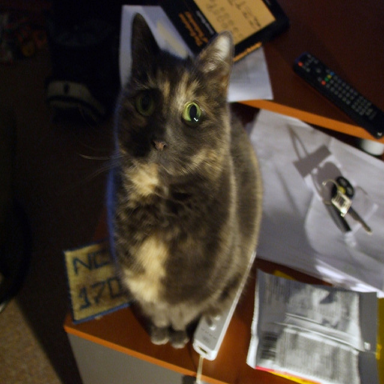

Ground Truth:


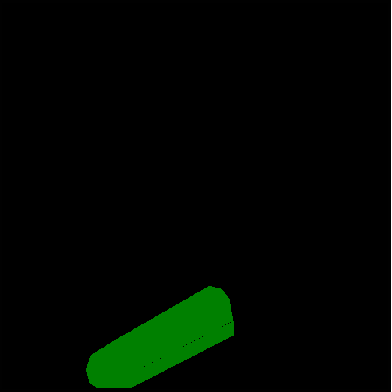

Prediction for DMTNet:


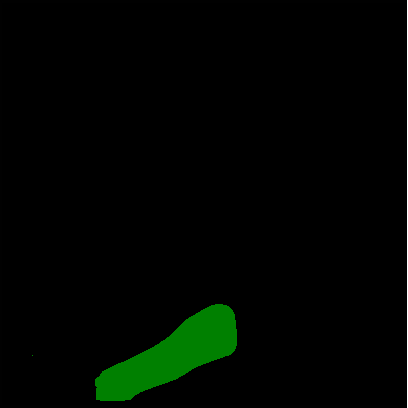

Prediction for DCAMA:


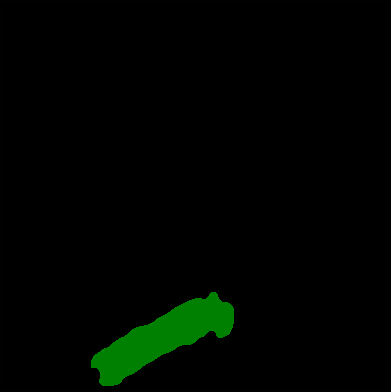

Explanation for DCAMA AE:


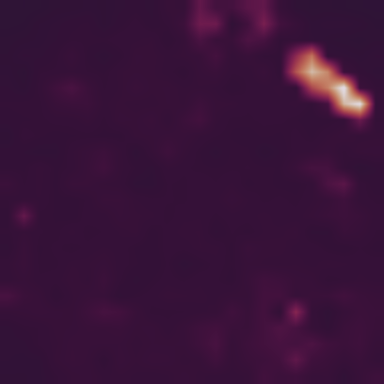

Explanation for DCAMA Saliency:


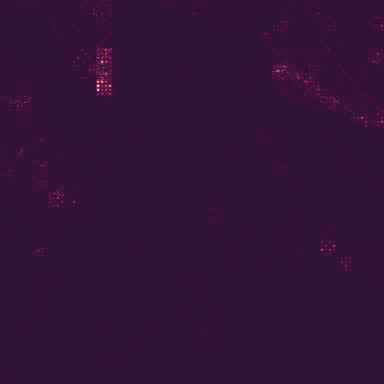

Explanation for DMTNet AE:


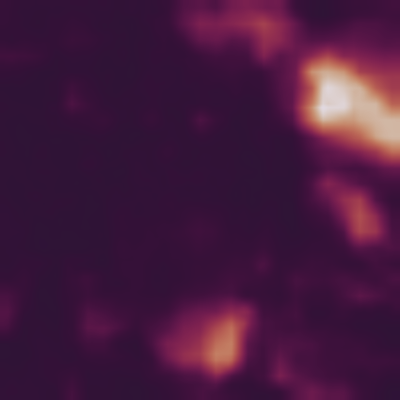

Explanation for DMTNet Saliency:


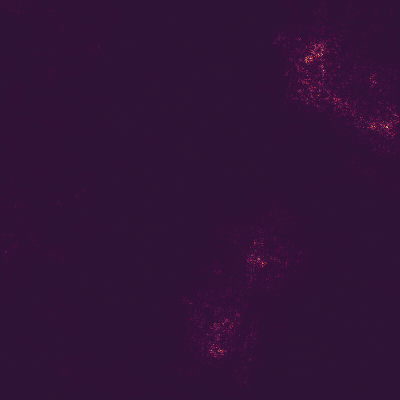

In [14]:
image_obj = Image.open(image)

left_width = image_obj.width // 2
right_width = image_obj.width - left_width
left_image = image_obj.crop((11, 12, left_width - 5, image_obj.height - 12))
right_image = image_obj.crop((left_width+3, 12, image_obj.width - 13, image_obj.height - 12))

ground_truth_obj = Image.open(ground_truth)
predictions_objs = {
    model: Image.open(predictions[model]) for model in predictions
}
explanations_objs = {
    model_method: Image.open(explanations[model_method]) for model_method in explanations
}
print("Left part of image:")
display(left_image)
print("Right part of image:")
display(right_image)
# Display the images
print("Ground Truth:")
display(ground_truth_obj)
for model, pred_obj in predictions_objs.items():
    print(f"Prediction for {model}:")
    display(pred_obj)
for model_method, expl_obj in explanations_objs.items():
    print(f"Explanation for {model_method}:")
    # Remove 11 pixel padding from all sides of the explanation image before displaying
    width, height = expl_obj.size
    cropped_expl = expl_obj.crop((11, 12, width - 13, height - 12))
    explanations_objs[model_method] = cropped_expl
    display(cropped_expl)
    
batch = {
    "query_image": left_image,
    "support_image": right_image,
    "ground_truth": ground_truth_obj,
    **{
        f"prediction_{model}": pred_obj for model, pred_obj in predictions_objs.items()
    },
    **{
        f"explanation_{model_method}": expl_obj for model_method, expl_obj in explanations_objs.items()
    }
}

In [7]:
out_path = "qualit/coco"
os.makedirs(f"{out_path}/{batch_path}", exist_ok=True)
for key, value in batch.items():
    value.save(f"{out_path}/{batch_path}/{key}.png")
print(f"Batch saved to {out_path}/{batch_path}")

Batch saved to qualit/coco/batch_800


---

In [8]:
out_path = "qualit/pascal"

